In [2]:


import math,os,copy

import numpy as np
import torch



import matplotlib.pyplot as plt 
import matplotlib.ticker as ticker

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif", # serif
    "font.sans-serif": "Helvetica", # Times, Palatino, Computer Modern Roman
})
from mpl_toolkits import mplot3d

import plotly.io as pio
import plotly
import plotly.express as px
# pio.renderers.default = 'svg'
# Default renderer: 'vscode'
# Available renderers:
#     ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
#      'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
#      'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
#      'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
#      'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']
# I needed to set:
pio.renderers.default = "notebook_connected"


from opts.asgm.nplasgm import PID
from opts.elpf.esfo import esLPF
from opts.elpf.fo import LPF


'''
Simulate Balanced Transient Behaviour of the Effective Step-size 
given an:
    - err_acc, of the eff.step-size to a final eff.step-size value
    - total_steps, in one training across the data-set
    - initial eff. step-size value
    - final eff. step-size value
    
    when initial value > final value, then initial is highest, final is lowest possible
    when initial value < final value, then initial is lowest, final is highest possible
'''
def show_effss_behaviour(err_acc=3e-1, total_steps=391, initial=1e-3, final=0):
    alpha_hat_begin = initial 
    alpha_hat_end = final

    kk, ak, alpha_hatk, salpha_hatk =[],[],[],[]

    stepsize = LPF(inplace=True)
    sstepsize = esLPF()

    spe = total_steps
    # e-accuracy to alpha_hat_end
    eps_alpha_hat = err_acc 
    # filter pole
    bt = np.exp(np.log(eps_alpha_hat)/spe)
    print(bt)
    
    for k in range(spe*2):
        kc = (((k) % (spe*1)) + 1) 
        # print(f"k={k}, kc={kc}")
        if kc == 1:
            alpha_hat = alpha_hat_begin
        else:
            noise = 0.0
            alpha_hat, _ = stepsize.compute(u=alpha_hat_end+noise,x=alpha_hat,beta=bt, mode=2)
    
        # a = alpha_hat_end + ((bt**(kc-1))*(alpha_hat_begin-alpha_hat_end))
        salpha_hat = sstepsize.compute(u=(alpha_hat_end),x_init=(alpha_hat_begin), noise_k=0, beta=(bt), step=kc)
                                
        # ak.append(a)
        alpha_hatk.append(alpha_hat)
        salpha_hatk.append(salpha_hat)
        kk.append(k)
    
    fig = plt.figure(figsize=(8,3))
    ax = fig.add_subplot()

    # ax.plot(kk,ak,'-.',label='gmo')
    ax.plot(kk,alpha_hatk,'-',label=r"$\hat{\alpha}$")
    ax.plot(kk,salpha_hatk,'-.',label=r"$\hat{\alpha}$")
    ax.set_ylabel("eff. step-size")
    ax.set_xlabel('steps')
    ax.legend(loc='best')
    plt.show()


0.9824882512783507


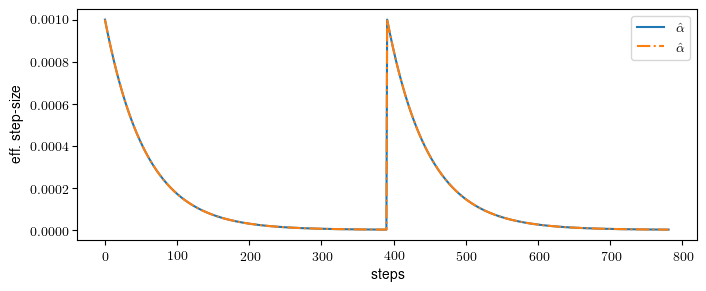

0.9969255215849246


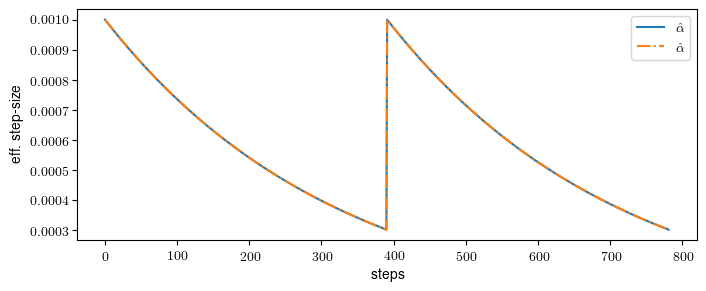

0.7079457843841379


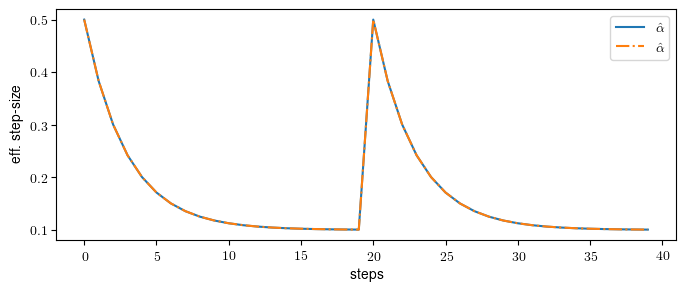

0.9659363289248456


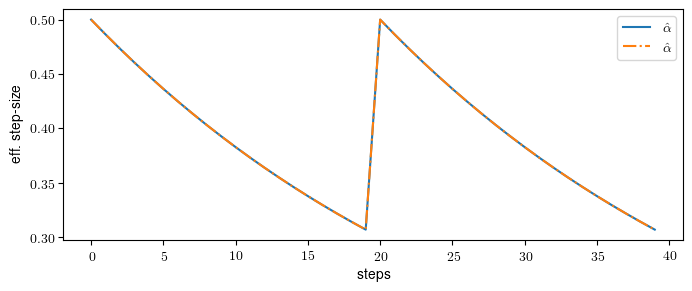

In [3]:

# -- Decrease or Decay

# err_acc=1e-3, total_steps=391, initial=1e-3, final=0
show_effss_behaviour(err_acc=1e-3, total_steps=391, initial=1e-3, final=0)
# err_acc=3e-1, total_steps=391, initial=1e-3, final=0
show_effss_behaviour(err_acc=3e-1, total_steps=391, initial=1e-3, final=0)

# err_acc=1e-3, total_steps=20, initial=1e-1, final=5e-1
show_effss_behaviour(err_acc=1e-3, total_steps=20, initial=5e-1, final=1e-1)
# err_acc=3e-1, total_steps=20, initial=1e-1, final=5e-1
show_effss_behaviour(err_acc=5e-1, total_steps=20, initial=5e-1, final=1e-1)


0.9824882512783507


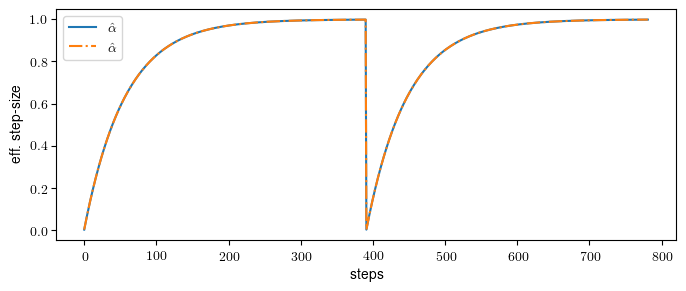

0.9982288154644244


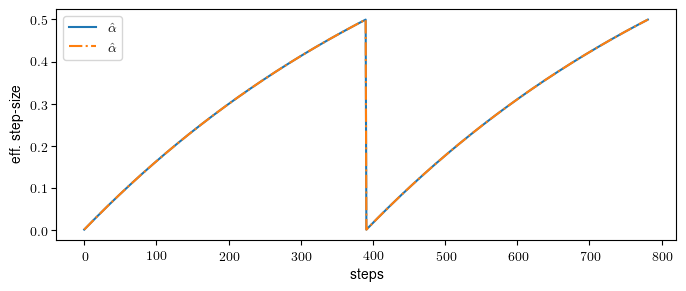

0.7943282347242815


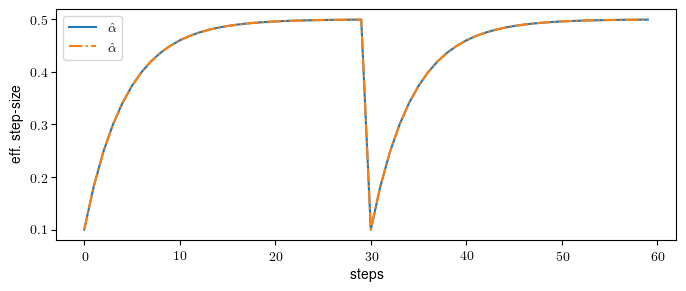

0.9771599684342459


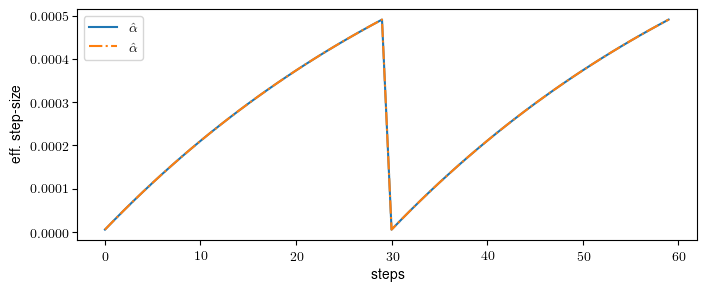

In [4]:

# -- Increase or Warm up

# err_acc=1e-3, total_steps=391, initial=1e-3, final=1
show_effss_behaviour(err_acc=1e-3, total_steps=391, initial=1e-3, final=1)
# err_acc=5e-1, total_steps=391, initial=1e-3, final=1
show_effss_behaviour(err_acc=5e-1, total_steps=391, initial=1e-3, final=1)

# err_acc=1e-3, total_steps=30, initial=1e-1, final=5e-1
show_effss_behaviour(err_acc=1e-3, total_steps=30, initial=1e-1, final=5e-1)
# err_acc=3e-1, total_steps=30, initial=1e-1, final=5e-1
show_effss_behaviour(err_acc=5e-1, total_steps=30, initial=5e-6, final=1e-3)